In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [34]:
def apresentaImg(imagem):
    img = plt.figure(figsize = (30,28))
    ax = img.add_subplot(111)
    ax.imshow(imagem, cmap = 'gray')
    # plt.axis('off')

In [35]:
caixa_papelao = cv2.imread('caixaPapelao.jpeg')
caixa_papelao = cv2.cvtColor(caixa_papelao, cv2.COLOR_BGR2GRAY)

caixa_desarrumada = cv2.imread('caixaBagunçando.jpeg')
caixa_desarrumada = cv2.cvtColor(caixa_desarrumada, cv2.COLOR_BGR2GRAY)

In [36]:
sift = cv2.SIFT_create()

In [37]:
kp1, des1 = sift.detectAndCompute(caixa_papelao, None)
kp2, des2 = sift.detectAndCompute(caixa_desarrumada, None)

In [38]:
bf = cv2.BFMatcher()

In [39]:
matches = bf.knnMatch(des1, des2, k=2)

In [40]:
good = []

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append([m])

In [41]:
resultado = cv2.drawMatchesKnn(caixa_papelao, kp1, caixa_desarrumada, kp2, good, None, flags = 2)

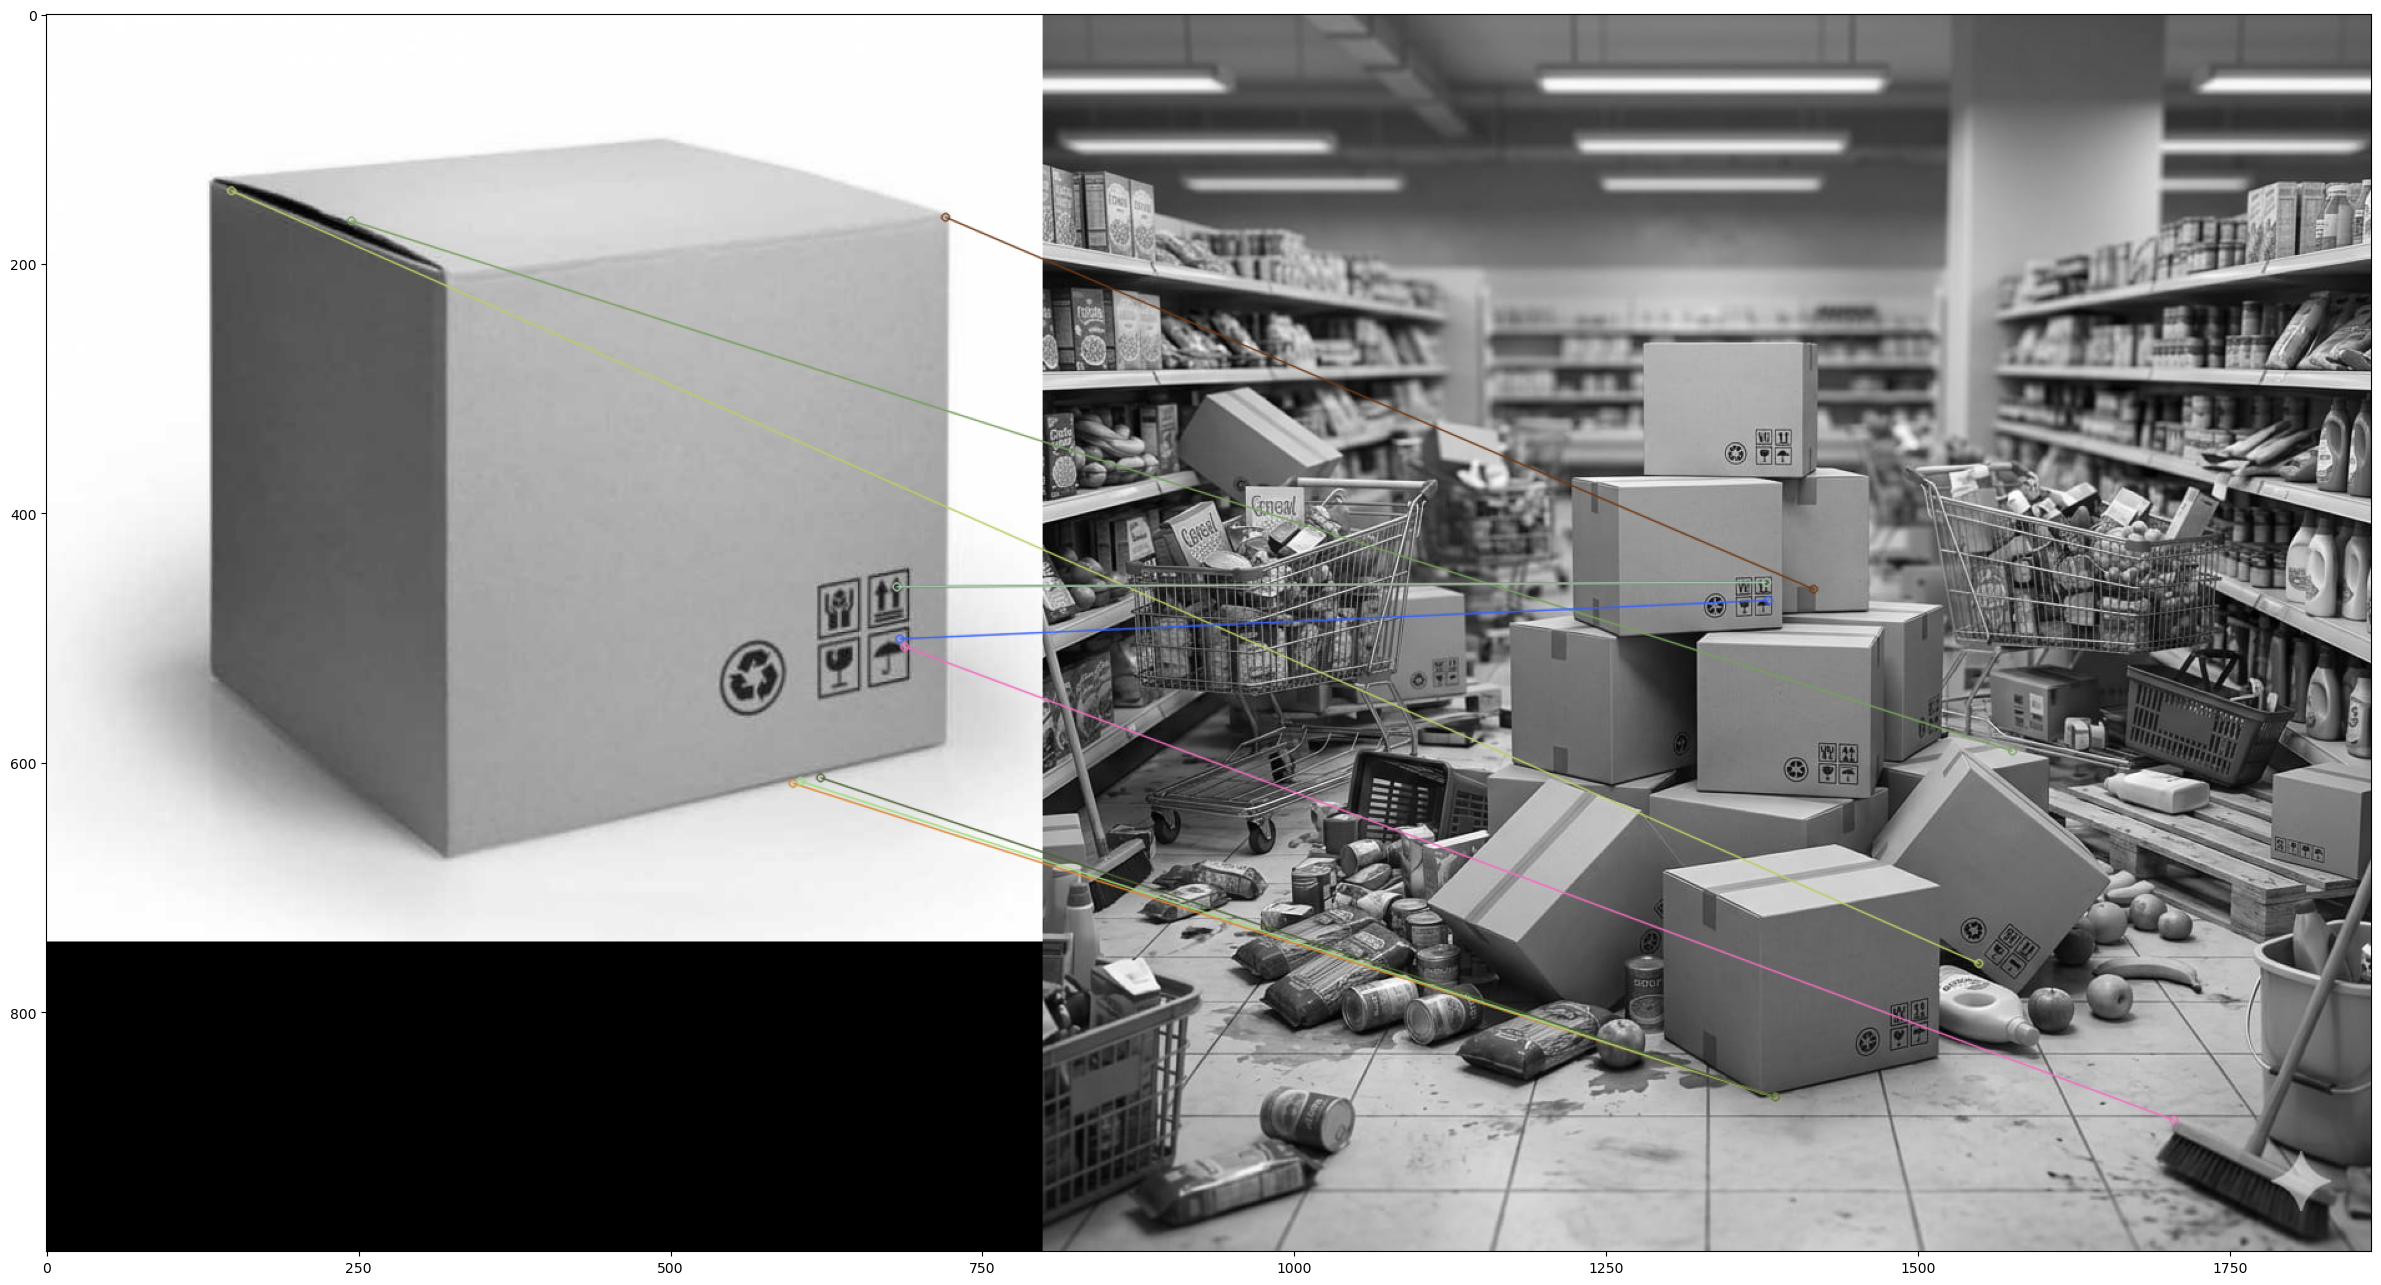

In [42]:
apresentaImg(resultado)